In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline, make_pipeline
from category_encoders import TargetEncoder
import statsmodels.api as sm
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, precision_recall_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import shap
from PyALE import ale
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
import keras
from sklearn.utils.class_weight import compute_class_weight
from functools import partial


from sklearn import set_config
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

Initialize

In [38]:
df = pd.read_csv('..\Data\loan_data_sample.csv')
features = ['loan_amnt', 'term', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'mths_since_last_major_derog',
       'application_type', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
       'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
       'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
       'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit',
       'months_sincefrst_credit', 'public_record', 'is_consolidation',
       'addr_state', 'is_currently_delinq', 'has_il_history']

index_sql = 'Loan_ID'
target = 'predictor'

df_features  = df[features]
df_predictor = pd.Series(df[target])


#Imputing col's we imputed with 999 in SQL
imputed_cols = [
    'mths_since_last_delinq', 'mths_since_last_record', 
    'mths_since_last_major_derog', 'mths_since_recent_bc_dlq', 
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq'
]

df_features.loc[:,imputed_cols] = df_features[imputed_cols].replace(999.0, np.nan)





X_train, X_test, y_train,y_test = train_test_split(df_features,df_predictor,stratify=df_predictor,test_size=.2,random_state=11)

categorical_features = X_train.select_dtypes(include=['object','category']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()

Pipeline for Flags / missing values  --- Target Encoding

In [39]:
zero_cols = [
    'max_bal_bc', 'all_util', 'il_util', 'open_acc_6m', 
    'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'inq_last_12m',
    'open_act_il', 'total_bal_il', 'total_il_high_credit_limit', 'is_consolidation'
]
flag_cols = [
    'mths_since_last_delinq', 'mths_since_last_record', 
    'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 
    'mths_since_recent_inq', 'mths_since_rcnt_il',
    'mths_since_last_major_derog'
]
median_cols = [
    'months_sincefrst_credit', 'annual_inc', 'inq_last_6mths', 
    'revol_util', 'total_acc', 'pub_rec', 'open_acc', 
    'mo_sin_old_rev_tl_op', 'num_rev_accts', 'tot_hi_cred_lim',
    'acc_open_past_24mths', 'num_bc_sats', 'num_sats', 'mort_acc',
    'mths_since_recent_bc', 'total_bc_limit', 'pub_rec_bankruptcies',
    'total_rev_hi_lim', 'inq_fi', 'avg_cur_bal', 'bc_open_to_buy', 
    'bc_util', 'mo_sin_old_il_acct', 'mo_sin_rcnt_rev_tl_op', 
    'mo_sin_rcnt_tl', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 
    'num_actv_rev_tl', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 
    'num_rev_tl_bal_gt_0', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 
    'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'total_cu_tl', 'total_bal_ex_mort', 'num_tl_30dpd', 'num_tl_120dpd_2m', 'chargeoff_within_12_mths'
]

ohe_cols = ['home_ownership', 'verification_status', 'application_type'] 
target_col = ['addr_state']

def make_ratio(X):
    eps = 0.001
    return ( X[:, [0]] / (X[:, [1]] + eps) )

def monthlycash(X):
    return ((X[:, [0]] / 12) * (1 - (X[:, [1]] / 100)))

def ratio_name(function_transformer, feature_names_in):
    return ['custom_ratio'] 

#Winsorizer 
from scipy.stats.mstats import winsorize

def winsorize_fn(X):
    return np.array(winsorize(np.array(X), limits=[0.01, 0.01], axis=0))

def make_winsorizer():
    return FunctionTransformer(winsorize_fn,feature_names_out='one-to-one')

zero_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value=0)),
    ('winsorize', make_winsorizer()),
    ('scale', StandardScaler())
])

median_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('winsorize', make_winsorizer()),
    ('scale', StandardScaler())
])

flag_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median', add_indicator=True)),
])

cat_ohe_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)) 
])

target_enc_pipe = Pipeline([
    ('target_encode', TargetEncoder(smoothing=10, handle_missing='value', handle_unknown='value')),
    ('scale', StandardScaler())
])

def ratio_pipe():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('ratio', FunctionTransformer(make_ratio, feature_names_out=ratio_name)),
        ('winsorize', make_winsorizer()),
        ('scale', StandardScaler())])

monthly_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('calc', FunctionTransformer(monthlycash, feature_names_out=ratio_name)),
    ('winsorize', make_winsorizer()),
    ('scale', StandardScaler())
])

set_config(transform_output="default")
preprocessor = ColumnTransformer(
    transformers=[
        ('zeros', zero_pipe, zero_cols),
        ('medians', median_pipe, median_cols),
        ('flags', flag_pipe, flag_cols),
        ('ohe', cat_ohe_pipe, ohe_cols),
        ('target', target_enc_pipe, target_col),
        
        #these are our ratio's
        ('FE_loan_to_income', ratio_pipe(), ['loan_amnt', 'annual_inc']),
        ('FE_activity_ratio', ratio_pipe(), ['num_actv_rev_tl', 'num_op_rev_tl']),
        ('my_monthly_cash', monthly_pipe, ['annual_inc', 'dti']) 
    ],
    remainder='drop' 
)



In [40]:
X_train_pre = preprocessor.fit_transform(X_train, y_train)
X_test_pre = preprocessor.transform(X_test)

# convert to pandas
X_train_pre = pd.DataFrame(X_train_pre, columns=preprocessor.get_feature_names_out())
X_test_pre = pd.DataFrame(X_test_pre, columns=preprocessor.get_feature_names_out())

In [ ]:
print(len(X_train_pre.columns),len(X_train.columns))

print(X_train_pre.shape)

possible more data needed? - no just overfitting
- add regularization, maybe dropout? 
    - Going to implement MC dropout?

global surrogate model / SHAPLEY

## Fine Tuning

In [13]:
import keras_tuner as kt

def build_model(hp):
    n_hidden = hp.Int('n_hidden',min_value=1,max_value=5,default=2)
    n_neurons = hp.Int('n_neurons',min_value=16,max_value=256,step=16)
    learning_rate = hp.Float('learning_rate',min_value=1e-4,max_value=1e-2,sampling='log')
    dropout_rate = hp.Float('dropout_rate',min_value=0,max_value=0.5,step=0.1)
    regularizer_type=hp.Choice('regularizer',values=['none','l1','l2','l1_l2'])
    use_lr_schedule = hp.Boolean('use_lr_schedule')

    #now for the regularizers

    if regularizer_type=='l1':
        reg = tf.keras.regularizers.L1(0.01)
    elif regularizer_type=='l2':
        reg = tf.keras.regularizers.L2(0.01)
    elif regularizer_type=='l1_l2':
        reg = tf.keras.regularizers.L1L2(0.01)
    else:
        reg = None
    
    #Tryig a learningR schedule

    if use_lr_schedule:
        lr = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=learning_rate,
            decay_rate=0.9,
            decay_steps=1000
        )

    else:
        lr = learning_rate

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(X_train_pre.shape[1],)))


    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(
            n_neurons,
            kernel_initializer='he_normal',
            use_bias=False,
            kernel_regularizer=reg
        ))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation('relu'))
        model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(1,activation='sigmoid'))

    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr),
        loss = 'binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='AUC'),
            tf.keras.metrics.Precision(name='Precision'),
            tf.keras.metrics.Recall(name='Recall')
        ]
    )

    return model



In [ ]:
X_train1 , X_val1, y_train1, y_val1 = train_test_split(X_train_pre, y_train,
                                                      stratify=y_train, train_size = 0.8,
                                                      random_state=11)

class_weights = compute_class_weight(class_weight='balanced',classes=np.unique(y_train),
                                     y=y_train)

class_weight_dict= dict(enumerate(class_weights))




tuner = kt.BayesianOptimization(
    build_model,
    objective = kt.Objective('val_AUC',direction = 'max'),
    max_trials = 30,
    overwrite  = False,
    directory = 'my_logs',
    project_name = 'ann_creditDefault',
    seed = 11
)

stop_early = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_AUC',
    patience=10,
    mode='max',
    restore_best_weights=True
)

tuner.search(
    X_train1,y_train1,
    epochs=50,
    validation_data = [X_val1,y_val1],
    callbacks = [stop_early],
    class_weight = class_weight_dict,
    batch_size = 256
)


tuner.results_summary(num_trials=5)


Trial 30 Complete [00h 01m 28s]
val_AUC: 0.6953237056732178

Best val_AUC So Far: 0.6976444721221924
Total elapsed time: 00h 54m 27s
Results summary
Results in my_logs\ann_creditDefault
Showing 5 best trials
Objective(name="val_AUC", direction="max")

Trial 17 summary
Hyperparameters:
n_hidden: 1
n_neurons: 64
learning_rate: 0.006191626495316131
dropout_rate: 0.4
regularizer: none
use_lr_schedule: True
Score: 0.6976444721221924

Trial 29 summary
Hyperparameters:
n_hidden: 1
n_neurons: 144
learning_rate: 0.01
dropout_rate: 0.4
regularizer: none
use_lr_schedule: False
Score: 0.6953237056732178

Trial 25 summary
Hyperparameters:
n_hidden: 1
n_neurons: 256
learning_rate: 0.007446600105041555
dropout_rate: 0.4
regularizer: none
use_lr_schedule: True
Score: 0.694380521774292

Trial 12 summary
Hyperparameters:
n_hidden: 3
n_neurons: 192
learning_rate: 0.00025071332274895686
dropout_rate: 0.30000000000000004
regularizer: none
use_lr_schedule: False
Score: 0.6938413977622986

Trial 04 summary
H

In [18]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print(best_hp.values,'\n',best_model)

{'n_hidden': 1, 'n_neurons': 64, 'learning_rate': 0.006191626495316131, 'dropout_rate': 0.4, 'regularizer': 'none', 'use_lr_schedule': True} 
 <Sequential name=sequential, built=True>


c:\Users\Marwa\anaconda3\envs\data_cleaning\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 11 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prereqs

Date/Time for running logs

In [41]:
from pathlib import Path
from time import strftime

def get_run_logdir(root_logdir='./my_logs'):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

### MODEL

In [42]:
X_train2,X_val2, y_train2,y_val2 = train_test_split(X_train_pre,y_train,train_size=0.8,random_state=11)

model = tf.keras.Sequential ([
    tf.keras.layers.Dense(64,kernel_initializer='he_normal',use_bias=False,
                          input_shape=(X_train_pre.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(rate=0.4),
    tf.keras.layers.Dense(1,activation='sigmoid')
])



model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.006191626495316131),
              loss='binary_crossentropy',
              metrics=[keras.metrics.AUC(name='AUC'),
                       keras.metrics.Precision(name='precision'),
                       keras.metrics.Recall(name='recall')])

tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,profile_batch=(100,200))
early_stop_cb = tf.keras.callbacks.EarlyStopping(patience=40,restore_best_weights=True,min_delta=0.001)


class_weights = compute_class_weight(class_weight='balanced',classes=np.unique(y_train),
                                     y=y_train)

class_weight_dict= dict(enumerate(class_weights))


history = model.fit(
    X_train1,y_train1,
    validation_data=(X_val2,y_val2),
    epochs=100,
    callbacks=[tensorboard_cb,early_stop_cb], 
    batch_size=256,
    class_weight=class_weight_dict
)


c:\Users\Marwa\anaconda3\envs\data_cleaning\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - AUC: 0.6456 - loss: 0.6652 - precision: 0.2784 - recall: 0.6299 - val_AUC: 0.6864 - val_loss: 0.6433 - val_precision: 0.2970 - val_recall: 0.6773
Epoch 2/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - AUC: 0.6765 - loss: 0.6439 - precision: 0.2944 - recall: 0.6434 - val_AUC: 0.6829 - val_loss: 0.7304 - val_precision: 0.2671 - val_recall: 0.8000
Epoch 3/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - AUC: 0.6811 - loss: 0.6408 - precision: 0.2972 - recall: 0.6474 - val_AUC: 0.6915 - val_loss: 0.6722 - val_precision: 0.2892 - val_recall: 0.7162
Epoch 4/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - AUC: 0.6836 - loss: 0.6400 - precision: 0.2996 - recall: 0.6501 - val_AUC: 0.6920 - val_loss: 0.6878 - val_precision: 0.2816 - val_recall: 0.7452
Epoch 5/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - AUC: 0.6855 - loss: 0.6387 - precision: 0.3014 - recall: 0.6512 - val_AUC: 0.6824 - val_loss: 0.8365 - val_precision: 0.2481 - val_reca

### Save model

In [ ]:
model.save('../models/ann_dense.keras')

In [53]:
model = tf.keras.models.load_model('../models/ann_dense.keras')


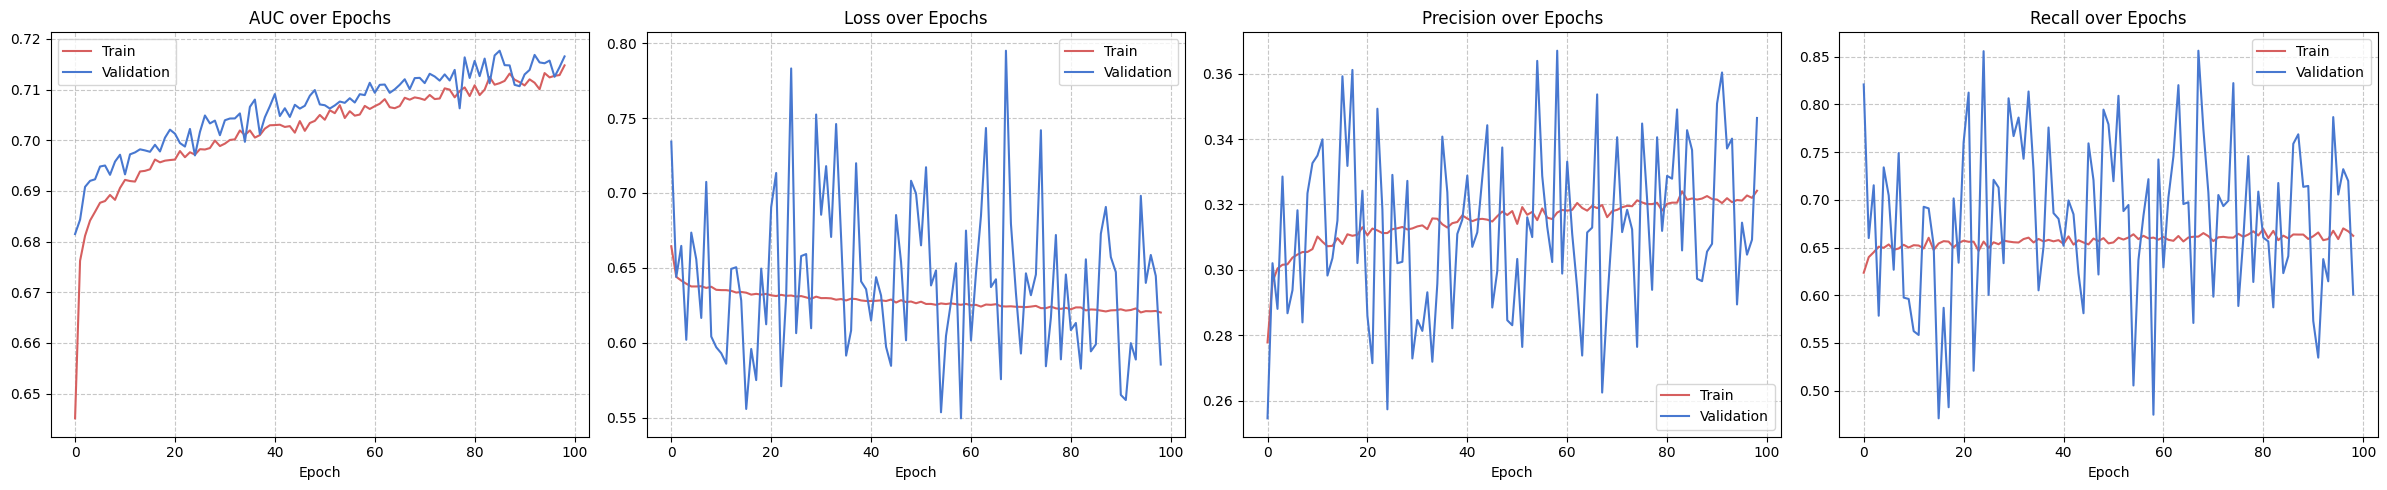

In [35]:
def plot_history(history, metrics=[('AUC', 'AUC'), ('loss', 'Loss')]):
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    
    for ax, (metric, title) in zip(axes, metrics):
        ax.plot(history.history[metric],        label='Train',      color='#d65f5f')
        ax.plot(history.history[f'val_{metric}'],label='Validation', color='#4878d0')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    #plt.savefig('Images/LearningCurve_baselineANN.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_history(history, metrics=[
    ('AUC',       'AUC over Epochs'),
    ('loss',      'Loss over Epochs'),
    ('precision', 'Precision over Epochs'),
    ('recall',    'Recall over Epochs')
])

Wide and Deep - neural network  - SHAPLY - Surrogate Model